In [7]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
import mpl_toolkits
import mpl_toolkits.mplot3d

In [8]:
homecomp = "D:"
titledpath = homecomp

In [9]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"
matplotlib.rcParams['svg.fonttype'] = 'none'

In [10]:
df = pd.read_excel(r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\2025 Complete raw values osar falling\Falling_20260131.xlsx")
exclude = ["R58", "Th-Gal4", "R76B09", "VT999036"]

df = df[~df["MBON"].isin(exclude)].reset_index(drop=True)
delta_g_cols = [col for col in df.columns if ("\u0394") in col]
delta_g_cols = [col for col in delta_g_cols if "pausepos_Δg" not in col and "Speed_Δg" not in col]
df_sub = df[["MBON", "responder"] + delta_g_cols].copy()
df_sub[delta_g_cols] = df_sub[delta_g_cols].abs()
means = df_sub.groupby("responder")[delta_g_cols].mean()
stds = df_sub.groupby("responder")[delta_g_cols].std()
counts = df_sub.groupby("responder")[delta_g_cols].count()

In [11]:
ci95_acr = 1.96 * stds.loc["ACR"].values / np.sqrt(counts.loc["ACR"].values)
ci95_chrimson = 1.96 * stds.loc["Chrimson2"].values / np.sqrt(counts.loc["Chrimson2"].values)

result = pd.DataFrame({
    "metric": delta_g_cols,
    "GtACR1": means.loc["ACR"].values,
    "GtACR1_CI_low": means.loc["ACR"].values - ci95_acr,
    "GtACR1_CI_high": means.loc["ACR"].values + ci95_acr,
    "CsChrimson": means.loc["Chrimson2"].values,
    "CsChrimson_CI_low": means.loc["Chrimson2"].values - ci95_chrimson,
    "CsChrimson_CI_high": means.loc["Chrimson2"].values + ci95_chrimson
})
result

,metric,GtACR1,GtACR1_CI_low,GtACR1_CI_high,CsChrimson,CsChrimson_CI_low,CsChrimson_CI_high
0,Fall number_ΔΔ,0.506841,0.330790,0.682892,0.758222,0.553610,0.962834
1,Average height climbed_Δg,0.297682,0.238906,0.356458,0.394644,0.285986,0.503303
2,Bout speed_Δg,0.189795,0.137020,0.242571,0.274022,0.189855,0.358189
3,Pause position_Δg,0.266727,0.199641,0.333813,0.416000,0.302947,0.529053
4,Max velocity_Δg,0.665295,0.551389,0.779202,0.333600,0.263451,0.403749
5,Straightness Index_Δg,0.321250,0.227957,0.414543,0.403978,0.308728,0.499228
6,Duration of bouts_Δg,0.214023,0.152412,0.275633,0.274689,0.209159,0.340219
7,Number of Bouts_Δg,0.296318,0.223861,0.368775,0.406467,0.311744,0.501189


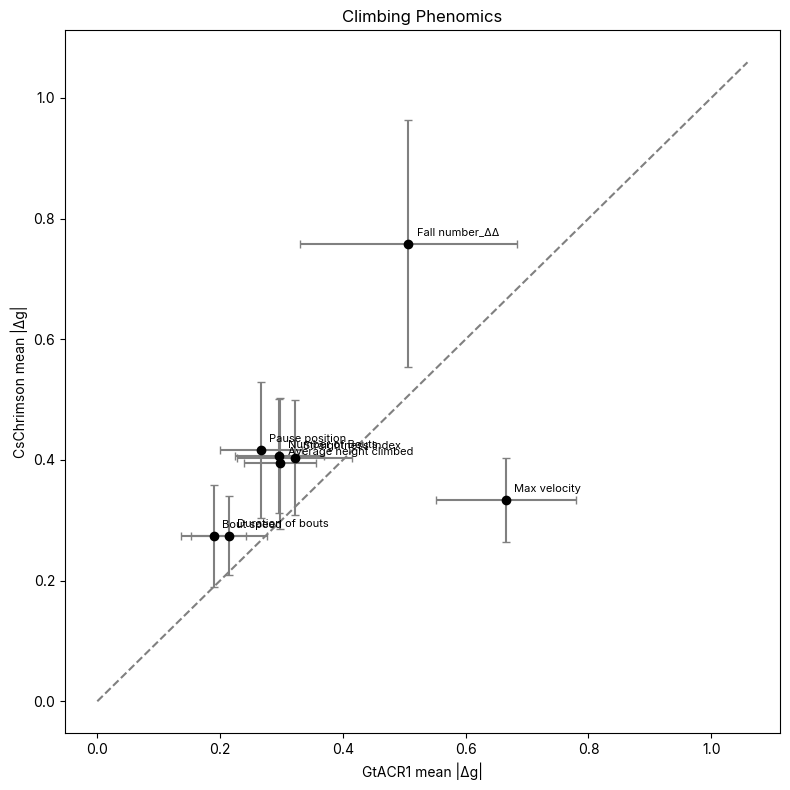

In [6]:
xerr_low = result["GtACR1"] - result["GtACR1_CI_low"]
xerr_high = result["GtACR1_CI_high"] - result["GtACR1"]
yerr_low = result["CsChrimson"] - result["CsChrimson_CI_low"]
yerr_high = result["CsChrimson_CI_high"] - result["CsChrimson"]

fig, ax = plt.subplots(figsize=(8, 8))
ax.errorbar(result["GtACR1"], result["CsChrimson"],
            xerr=[xerr_low, xerr_high], yerr=[yerr_low, yerr_high],
            fmt="o", capsize=3, color="black", ecolor="gray")

for i, row in result.iterrows():
    label = row["metric"].replace("_\u0394g", "")
    ax.annotate(label, (row["GtACR1"], row["CsChrimson"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8)

max_val = max(result["GtACR1_CI_high"].max(), result["CsChrimson_CI_high"].max()) * 1.1
ax.plot([0, max_val], [0, max_val], linestyle="--", color="gray")

ax.set_xlabel("GtACR1 mean |\u0394g|")
ax.set_ylabel("CsChrimson mean |\u0394g|")
ax.set_title("Climbing Phenomics")
plt.tight_layout()
plt.show()

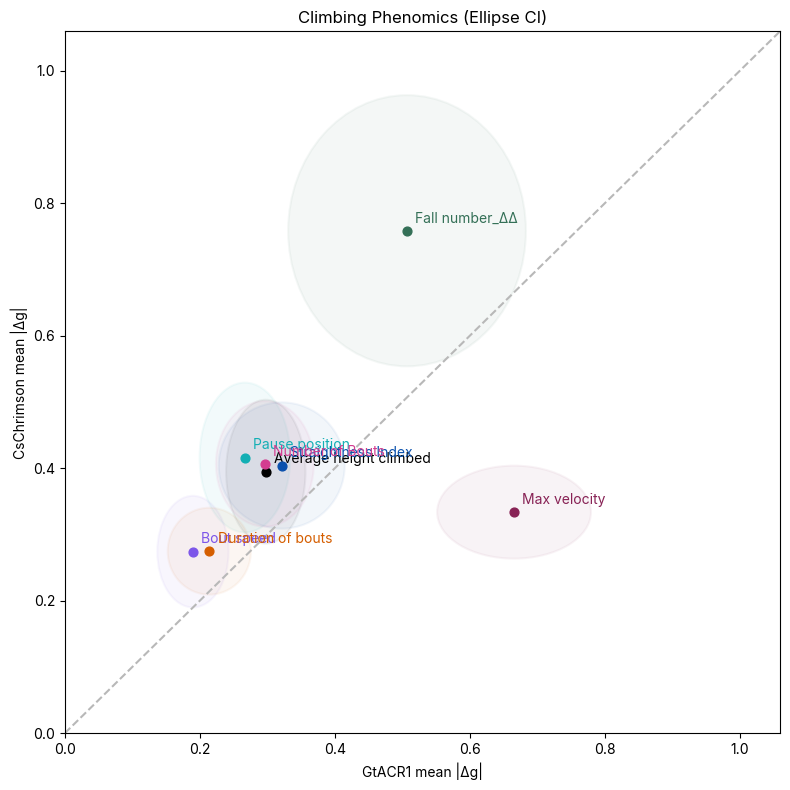

In [ ]:
from matplotlib.patches import Ellipse
## Metric ellipse shading
colors = [
      # black
 "#347057",
 '#000000',
    "#7D56E9",
    # sky blue
     "#13AFB4",# bluish green
    '#882255',  # wine
    "#0A51AD",  # blue
    '#D55E00',  # vermillion
    "#D33D90",  # reddish purple
]

fig, ax = plt.subplots(figsize=(8, 8))

for i, row in result.iterrows():
    w = row["GtACR1_CI_high"] - row["GtACR1_CI_low"]
    h = row["CsChrimson_CI_high"] - row["CsChrimson_CI_low"]
    ellipse = Ellipse((row["GtACR1"], row["CsChrimson"]), width=w, height=h,
                       facecolor=colors[i], alpha=0.05, edgecolor=colors[i], linewidth=1.5)
    ax.add_patch(ellipse)
    ax.scatter(row["GtACR1"], row["CsChrimson"], color=colors[i], s=40, zorder=3)
    label = row["metric"].replace("_\u0394g", "")
    ax.annotate(label, (row["GtACR1"], row["CsChrimson"]),
                textcoords="offset points", xytext=(6, 6), fontsize=10, color=colors[i])

max_val = max(result["GtACR1_CI_high"].max(), result["CsChrimson_CI_high"].max()) * 1.1
ax.plot([0, max_val], [0, max_val], linestyle="--", color="#B8B8B8")

ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_xlabel("GtACR1 mean |\u0394g|")
ax.set_ylabel("CsChrimson mean |\u0394g|")
ax.set_title("Climbing Phenomics (Ellipse CI)")
plt.tight_layout()
#plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\images\\Climbing phenomics_responder means.svg", bbox_inches="tight")
plt.show()

In [12]:
exclude = ["Fall number_ΔΔ", "Pause position_Δg"]
delta_g_only_cols = [c for c in delta_g_cols if c not in exclude]
df_sub["locomotor_mean"] = df_sub[delta_g_only_cols].mean(axis=1)
mbon_loco = df_sub.pivot_table(index="MBON", columns="responder", values="locomotor_mean")
mbon_loco = mbon_loco.dropna()
# mbon_loco = mbon_loco[~((mbon_loco["ACR"] < 0.2) & (mbon_loco["Chrimson2"] < 0.2))]

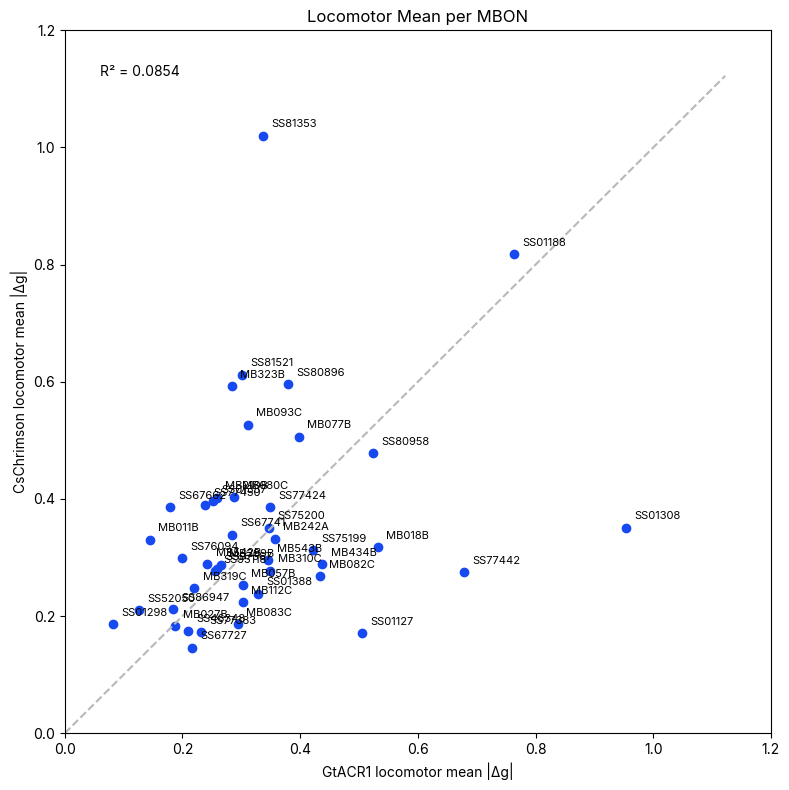

In [46]:
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(mbon_loco["ACR"], mbon_loco["Chrimson2"])
r_squared = r_value**2

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(mbon_loco["ACR"], mbon_loco["Chrimson2"], color="#1749F0")

for mbon in mbon_loco.index:
    ax.annotate(mbon, (mbon_loco.loc[mbon, "ACR"], mbon_loco.loc[mbon, "Chrimson2"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8)

max_val = max(mbon_loco["ACR"].max(), mbon_loco["Chrimson2"].max()) * 1.1
ax.plot([0, max_val], [0, max_val], linestyle="--", color="#B8B8B8")

ax.text(0.05, 0.95, f"R\u00b2 = {r_squared:.4f}", transform=ax.transAxes,
        fontsize=10, verticalalignment="top")

ax.set_ylim(0,1.2)
ax.set_xlim(0,1.2)
ax.set_xlabel("GtACR1 locomotor mean |\u0394g|")
ax.set_ylabel("CsChrimson locomotor mean |\u0394g|")
ax.set_title("Locomotor Mean per MBON")
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\images\\Climbing phenomics_lcoomotor means.svg", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [57]:
highlight_mbons = ["MB077B", "MB093C", "SS81353", "SS81521", "MB323B", "SS77450", "SS01188", "SS80958",
                   "SS80896", "SS77442", "SS01127",  "SS01308", "SS67662"]

distances = []
for mbon in highlight_mbons:
    if mbon in mbon_loco.index:
        x0 = mbon_loco.loc[mbon, "ACR"]
        y0 = mbon_loco.loc[mbon, "Chrimson2"]
        perp_dist = abs(x0 - y0) / np.sqrt(2)
        origin_dist = np.sqrt(x0**2 + y0**2)
        distances.append({"MBON": mbon, "ACR": round(x0, 4), "Chrimson2": round(y0, 4),
                          "Perpendicular distance to y=x": round(perp_dist, 4),
                          "Distance from origin": round(origin_dist, 4)})

df_distances = pd.DataFrame(distances)
df_distances

,MBON,ACR,Chrimson2,Perpendicular distance to y=x,Distance from origin
0,MB077B,0.3977,0.5065,0.0770,0.6440
1,MB093C,0.3107,0.5265,0.1526,0.6113
2,SS81353,0.3362,1.0203,0.4838,1.0743
3,SS81521,0.3008,0.6122,0.2201,0.6821
4,MB323B,0.2843,0.5923,0.2178,0.6570
5,SS77450,0.2385,0.3900,0.1071,0.4571
6,SS01188,0.7637,0.8178,0.0383,1.1189
7,SS80958,0.5240,0.4785,0.0322,0.7096
8,SS80896,0.3798,0.5962,0.1530,0.7069
9,SS77442,0.6790,0.2745,0.2860,0.7324


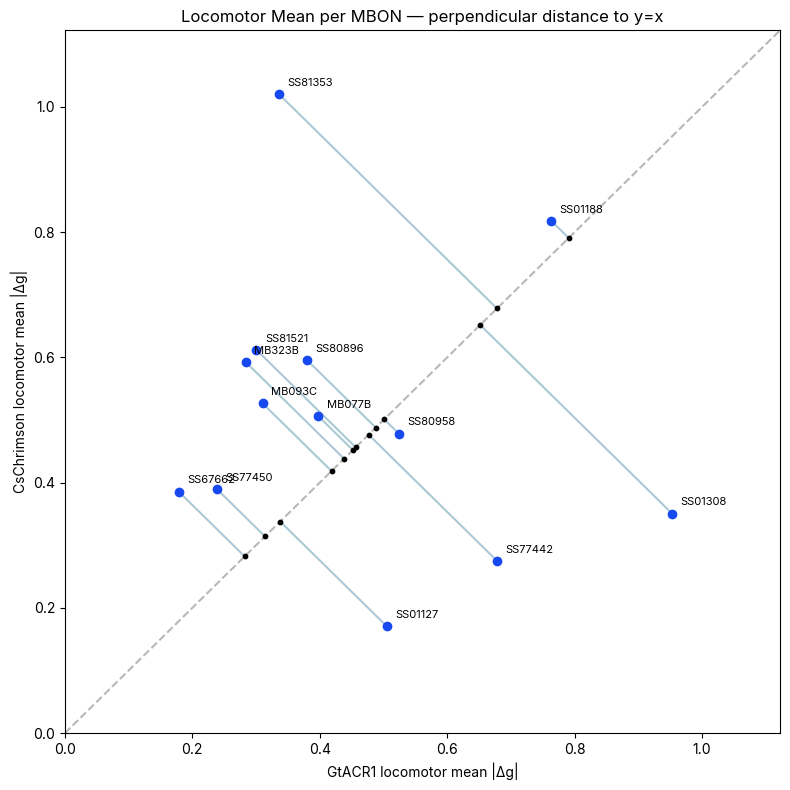

In [59]:
fig, ax = plt.subplots(figsize=(8, 8))
mbon_highlight = mbon_loco.loc[mbon_loco.index.isin(highlight_mbons)]
ax.scatter(mbon_highlight["ACR"], mbon_highlight["Chrimson2"], color="#1749F0", zorder = 3)

for mbon in mbon_highlight.index:
      ax.annotate(mbon, (mbon_highlight.loc[mbon, "ACR"], mbon_highlight.loc[mbon, "Chrimson2"]), zorder = 4,
                textcoords="offset points", xytext=(6, 6), fontsize=8)

max_val = max(mbon_loco["ACR"].max(), mbon_loco["Chrimson2"].max()) * 1.1
ax.plot([0, max_val], [0, max_val], linestyle="--", color="#B8B8B8")

for _, row in df_distances.iterrows():
    x0, y0 = row["ACR"], row["Chrimson2"]
    foot = (x0 + y0) / 2
    ax.plot([x0, foot], [y0, foot], color="#5693AC", linewidth=1.5, linestyle="-", alpha = 0.5, zorder=1)
    ax.scatter(foot, foot, color="#000000", s=10, zorder=5)

ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_xlabel("GtACR1 locomotor mean |Δg|")
ax.set_ylabel("CsChrimson locomotor mean |Δg|")
ax.set_title("Locomotor Mean per MBON — perpendicular distance to y=x")

plt.rcParams["font.family"] = "Inter"
matplotlib.rcParams['svg.fonttype'] = 'none'
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\images\\perpendicular distance.svg", bbox_inches = "tight")
plt.tight_layout()
plt.show()

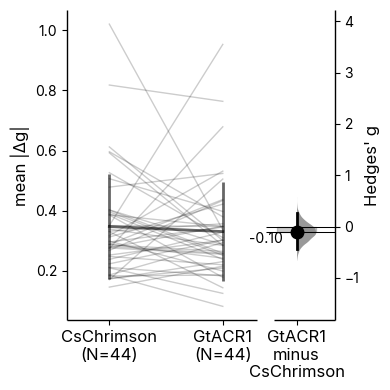

In [22]:
import dabest

dabest_climb = mbon_loco.rename(columns={"ACR": "GtACR1", "Chrimson2": "CsChrimson"}).reset_index()

paired_climb = dabest.load(
    dabest_climb,
    idx=("CsChrimson", "GtACR1"),
    paired="baseline",
    id_col="MBON"
)

plt.rcParams["font.family"] = "Inter"
matplotlib.rcParams['svg.fonttype'] = 'none'

compare = paired_climb.hedges_g.plot();
compare.axes[0].set_ylabel("mean |Δg|")
compare.axes[1].set_ylabel("Hedges' g")
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\images\\Pairedcomparison.svg", bbox_inches = "tight")
plt.tight_layout()